In [22]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import pytz

import trajectory as T
from PlanetaryData import Earth, Luna, Sun
from Spice import SpiceImporter

In [10]:
def circle_points(radius, position = None):
    p = position if position else (0,0)
    t = np.linspace(0, np.pi * 2, 100)
    return [radius * np.cos(t) + p[0], radius * np.sin(t) + p[1]]

In [23]:
spicer = SpiceImporter()
spicer.download_kernels()
spicer.load_kernels()

t = datetime(2026, 6, 13, 11, 25, 00, tzinfo=pytz.utc)

moon_data = spicer.get_state(body_name="MOON", time=t, observer="MOON")
earth_data = spicer.get_state(body_name="EARTH", time=t, observer="MOON")
sun_data = spicer.get_state(body_name="SUN", time=t, observer="MOON")

print(moon_data)
print(earth_data)
print(sun_data)

  naif0012.tls already exists
  gm_de440.tpc already exists
  earth_latest_high_prec.bpc already exists
  de440.bsp already exists
  moon_pa_de440_200625.bpc already exists
Download complete!
Loaded: naif0012.tls
Loaded: gm_de440.tpc
Loaded: de440.bsp
Loaded: earth_latest_high_prec.bpc
Loaded: moon_pa_de440_200625.bpc
{'name': 'MOON', 'time': datetime.datetime(2026, 6, 13, 11, 25, tzinfo=<UTC>), 'position': (np.float64(0.0), np.float64(0.0), np.float64(0.0))}
{'name': 'EARTH', 'time': datetime.datetime(2026, 6, 13, 11, 25, tzinfo=<UTC>), 'position': (np.float64(-186683.7836890456), np.float64(-267712.9161101574), np.float64(-150348.4803498691))}
{'name': 'SUN', 'time': datetime.datetime(2026, 6, 13, 11, 25, tzinfo=<UTC>), 'position': (np.float64(20663888.29961702), np.float64(137804952.6267263), np.float64(59701925.59536826))}


In [ ]:
# If we want to do stuff like eclipse
Luna.position = moon_data["position"]
Earth.position = earth_data["position"] # w.r.t Moon
Sun.position = sun_data["position"] # w.r.t Moon

body = Luna
# State
r = 1500 + body.radius
v = np.sqrt(body.mu / r)
orb_period = 2 * np.pi * np.sqrt(r*r*r/body.mu)
print(f"T = {orb_period}s")
state0 = [
    r, 0, 0,
    0, v, 0]

# Time
tf = orb_period / 2
dt = 0.1

# Propagator
op = T.OrbitPropagator(state0, tf, dt, [Sun, Earth, Luna])
op.simulate()

T = 16525.074464841775s


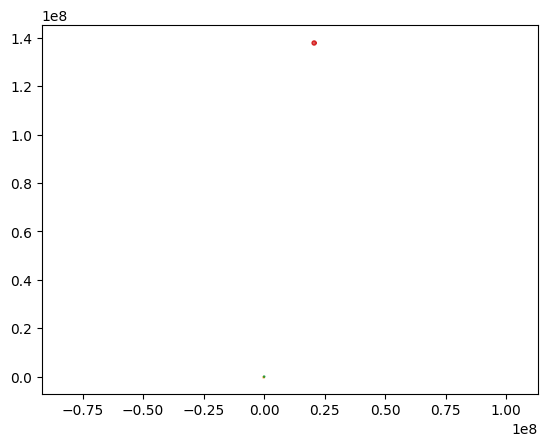

In [25]:
plt.plot(op.states[:,0], op.states[:,1])
plt.plot(*circle_points(Earth.radius, Earth.position[0:2]))
plt.plot(*circle_points(Luna.radius, Luna.position[0:2]))
plt.plot(*circle_points(Sun.radius, Sun.position[0:2]))
plt.axis('equal')
plt.show()